# Glacier Mass Balance Modeling
## Numerical ODE Analysis of Glacial Tipping Points
**GP 145/245 — Computational Earth System Analysis**  
**Milo Skapinsky, Stanford University, Spring 2026**

---

This notebook implements and analyzes the Oerlemans (2012) glacier length ODE model to investigate critical warming thresholds and bifurcation behavior. We implement Euler and RK4 solvers from scratch, extend the model with a nonlinear term, and use Numba JIT compilation and parallelism to accelerate parameter sweeps.

**Scientific question:** At what critical warming threshold ΔT* does glacier retreat become irreversible, and how does this depend on model parameters and initial conditions?

**Reference:** Oerlemans, J. (2012). Linear modelling of glacier length fluctuations. *Geografiska Annaler: Series A, Physical Geography*, 94(2), 183-194.

## 1. Model Setup & Parameters

The Oerlemans linear glacier model describes glacier length anomaly $L'$ (deviation from reference length) as:

$$\frac{dL'}{dt} = \frac{1}{\tau}(kE' - L')$$

Where:
- $L'$ — glacier length anomaly (km), deviation from pre-warming reference length
- $E' = \beta \cdot \Delta T$ — snowline elevation anomaly (m), proxy for temperature forcing
- $k$ — climate sensitivity (km/m): converts snowline rise to glacier shortening
- $\tau$ — response timescale (years): how slowly the glacier adjusts
- $\beta$ — snowline sensitivity (m/°C): how much the snowline rises per degree of warming

The analytical solution (via integrating factor) is:
$$L'(t) = kE'\left(1 - e^{-t/\tau}\right)$$

Parameters are taken from Oerlemans (2012), calibrated to large glacier systems 
(e.g. Himalayan, Greenlandic glaciers).

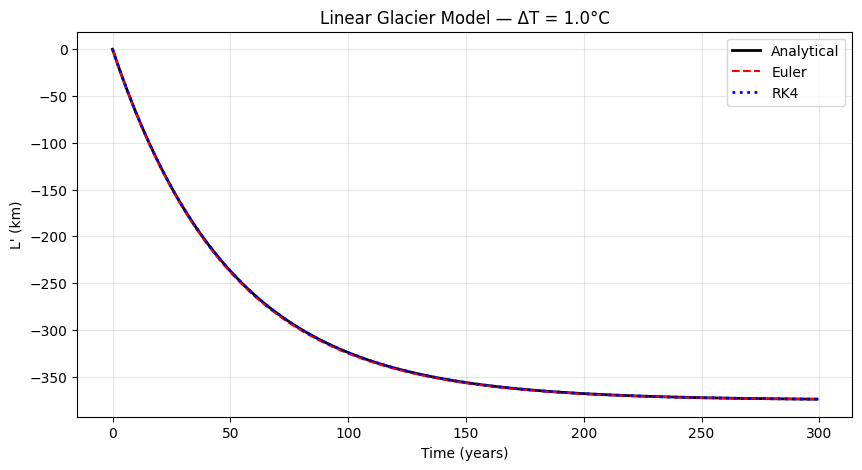

Euler MSE: 0.592565
RK4 MSE:   0.000000


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import time

# ── Parameters (Oerlemans 2012) ──────────────────────────────
tau = 50       # response timescale (years)
k = -2.5       # climate sensitivity (km/m)
beta = 150     # snowline sensitivity (m/°C)
L0 = 0.0       # initial anomaly (km)

# ── Analytical solution ──────────────────────────────────────
def analytical(t, E_prime, tau=tau, k=k):
    return k * E_prime * (1 - np.exp(-t / tau))

# ── Euler solver ─────────────────────────────────────────────
def euler(E_prime, dt, t_end, tau=tau, k=k, L0=L0):
    t = np.arange(0, t_end, dt)
    L = np.zeros(len(t))
    L[0] = L0
    for i in range(1, len(t)):
        dL = (1/tau) * (k * E_prime - L[i-1])
        L[i] = L[i-1] + dt * dL
    return t, L

# ── RK4 solver ───────────────────────────────────────────────
def rk4(E_prime, dt, t_end, tau=tau, k=k, L0=L0):
    def f(L):
        return (1/tau) * (k * E_prime - L)
    t = np.arange(0, t_end, dt)
    L = np.zeros(len(t))
    L[0] = L0
    for i in range(1, len(t)):
        k1 = f(L[i-1])
        k2 = f(L[i-1] + dt/2 * k1)
        k3 = f(L[i-1] + dt/2 * k2)
        k4 = f(L[i-1] + dt * k3)
        L[i] = L[i-1] + dt/6 * (k1 + 2*k2 + 2*k3 + k4)
    return t, L

# ── Test: compare solvers to analytical ──────────────────────
dt = 1.0
t_end = 300
delta_T = 1.0
E_prime = beta * delta_T

t_euler, L_euler = euler(E_prime, dt, t_end)
t_rk4, L_rk4 = rk4(E_prime, dt, t_end)
t_anal = np.arange(0, t_end, dt)
L_anal = analytical(t_anal, E_prime)

plt.figure(figsize=(10, 5))
plt.plot(t_anal, L_anal, 'k-', linewidth=2, label='Analytical')
plt.plot(t_euler, L_euler, 'r--', label='Euler')
plt.plot(t_rk4, L_rk4, 'b:', linewidth=2, label='RK4')
plt.xlabel('Time (years)')
plt.ylabel("L' (km)")
plt.title(f'Linear Glacier Model — ΔT = {delta_T}°C')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"Euler MSE: {np.mean((L_euler - L_anal)**2):.6f}")
print(f"RK4 MSE:   {np.mean((L_rk4 - L_anal)**2):.6f}")

## 2. Warming Scenarios — Linear Model

We sweep $\Delta T$ from 0 to 2°C and run the RK4 solver for each scenario. In the 
linear model, every warming scenario converges to a new stable equilibrium $L^* = kE'$, 
so no tipping point exists. Stronger warming produces a smaller but stable glacier.


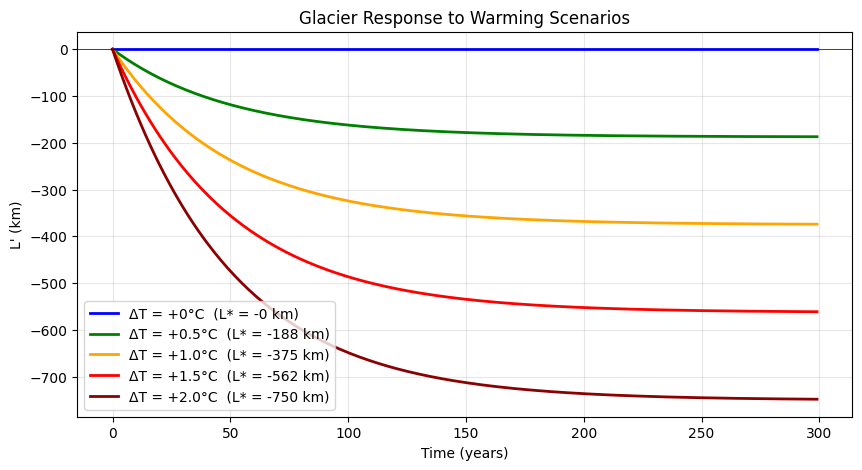

Equilibrium lengths:
  ΔT = 0°C → L* = -0.0 km
  ΔT = 0.5°C → L* = -187.5 km
  ΔT = 1.0°C → L* = -375.0 km
  ΔT = 1.5°C → L* = -562.5 km
  ΔT = 2.0°C → L* = -750.0 km


In [2]:
# ── Warming scenarios ─────────────────────────────────────────
delta_Ts = [0, 0.5, 1.0, 1.5, 2.0]
colors = ['blue', 'green', 'orange', 'red', 'darkred']
dt = 1.0
t_end = 300

plt.figure(figsize=(10, 5))

for dT, color in zip(delta_Ts, colors):
    E_prime = beta * dT
    t, L = rk4(E_prime, dt, t_end)
    eq = k * E_prime  # equilibrium L* = kE'
    plt.plot(t, L, color=color, linewidth=2, label=f'ΔT = +{dT}°C  (L* = {eq:.0f} km)')

plt.xlabel('Time (years)')
plt.ylabel("L' (km)")
plt.title('Glacier Response to Warming Scenarios')
plt.legend()
plt.grid(True, alpha=0.3)
plt.axhline(0, color='black', linewidth=0.5)
plt.show()

# Print equilibrium values
print("Equilibrium lengths:")
for dT in delta_Ts:
    E_prime = beta * dT
    print(f"  ΔT = {dT}°C → L* = {k * E_prime:.1f} km")

## 3. Solver Accuracy vs Runtime: Euler vs RK4

We compare Euler (1st order) and RK4 (4th order) across a range of time steps $\Delta t$, measuring MSE against the analytical solution.

**Euler:** ${i+1} = L_i + \Delta t \cdot f(L_i)$,  one slope evaluation per step.

**RK4:** Uses four slope evaluations per step (at start, two midpoints, end) for a weighted average resulting in more accuracy at the same $\Delta t$.

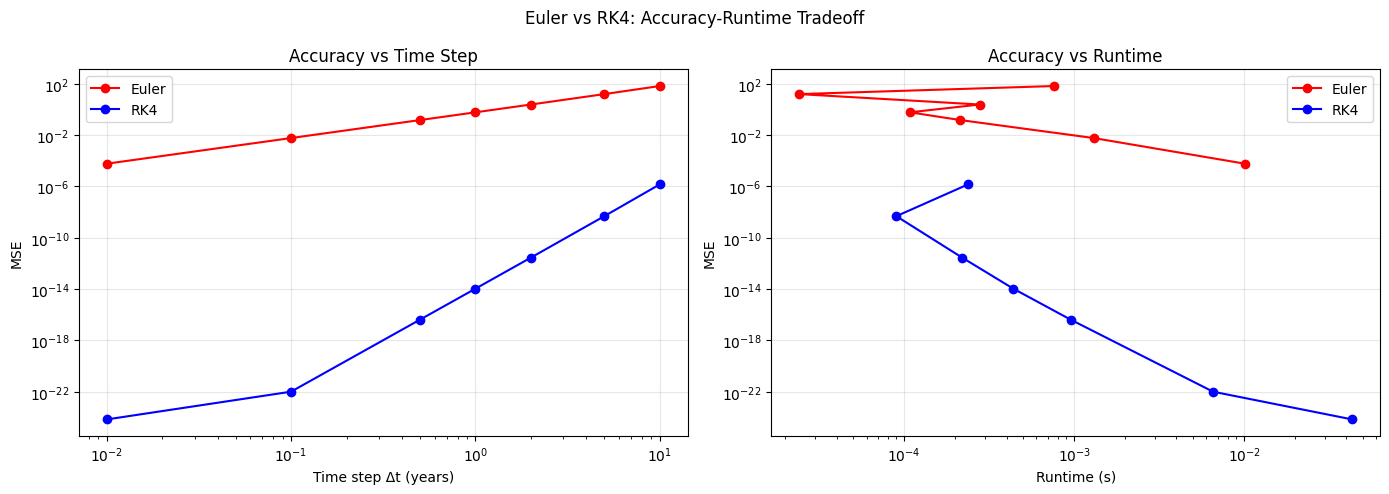

      dt    Euler MSE      RK4 MSE    Euler t      RK4 t
   10.00    66.444002     0.000001   0.000766   0.000238
    5.00    15.556303     0.000000   0.000024   0.000090
    2.00     2.398742     0.000000   0.000278   0.000219
    1.00     0.592565     0.000000   0.000108   0.000439
    0.50     0.147269     0.000000   0.000214   0.000955
    0.10     0.005863     0.000000   0.001303   0.006564
    0.01     0.000059     0.000000   0.010133   0.043322


In [3]:
# ── Step 3: Accuracy vs Runtime analysis ─────────────────────
dt_values = [10.0, 5.0, 2.0, 1.0, 0.5, 0.1, 0.01]
t_end = 300
E_prime = beta * 1.0  # ΔT = 1°C

euler_mse = []
rk4_mse = []
euler_times = []
rk4_times = []

for dt in dt_values:
    t_ref = np.arange(0, t_end, dt)
    L_anal = analytical(t_ref, E_prime)
    
    # Time Euler
    t0 = time.time()
    _, L_euler = euler(E_prime, dt, t_end)
    euler_times.append(time.time() - t0)
    euler_mse.append(np.mean((L_euler - L_anal)**2))
    
    # Time RK4
    t0 = time.time()
    _, L_rk4 = rk4(E_prime, dt, t_end)
    rk4_times.append(time.time() - t0)
    rk4_mse.append(np.mean((L_rk4 - L_anal)**2))

# Plot MSE vs dt
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.loglog(dt_values, euler_mse, 'r-o', label='Euler')
ax1.loglog(dt_values, rk4_mse, 'b-o', label='RK4')
ax1.set_xlabel('Time step Δt (years)')
ax1.set_ylabel('MSE')
ax1.set_title('Accuracy vs Time Step')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.loglog(euler_times, euler_mse, 'r-o', label='Euler')
ax2.loglog(rk4_times, rk4_mse, 'b-o', label='RK4')
ax2.set_xlabel('Runtime (s)')
ax2.set_ylabel('MSE')
ax2.set_title('Accuracy vs Runtime')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.suptitle('Euler vs RK4: Accuracy-Runtime Tradeoff')
plt.tight_layout()
plt.show()

# Print table
print(f"{'dt':>8} {'Euler MSE':>12} {'RK4 MSE':>12} {'Euler t':>10} {'RK4 t':>10}")
for i, dt in enumerate(dt_values):
    print(f"{dt:>8.2f} {euler_mse[i]:>12.6f} {rk4_mse[i]:>12.6f} {euler_times[i]:>10.6f} {rk4_times[i]:>10.6f}")

### 3 Analytical T* from Bifurcation Condition

Before introducing the nonlinear model numerically, we derive the critical temperature analytically.

Setting $dL'/dt = 0$ for the nonlinear model gives a quadratic in $L^*$:
$$\alpha\tau L^{*2} + L^* - kE' = 0$$

The bifurcation occurs when real equilibrium solutions cease to exist, when the discriminant goes to zero:
$$1 + 4\alpha\tau kE^* = 0 \implies \Delta T^* = \frac{-1}{4\alpha\tau k\beta}$$

This gives the **true mathematical tipping point**, any warming above this value means 
no stable equilibrium exists and the glacier is mathematically committed to collapse 
over infinite time.

In [28]:
# ── Analytical T* from bifurcation condition ─────────────────

# At T*, the discriminant of the equilibrium quadratic goes to zero:
# dL'/dt = (1/tau)(kE' - L') - alpha*L'^2 = 0
# Rearranging: alpha*tau*L'^2 + L' - kE' = 0
# Discriminant = 1 + 4*alpha*tau*kE' = 0
# Solving for E* then converting to ΔT*:

T_star_analytical = -1 / (4 * alpha * tau * k * beta)
print(f"Analytical derivation of T*:")
print(f"  From bifurcation condition: 1 + 4αkτE' = 0")
print(f"  E* = -1/(4ατk) = {-1/(4*alpha*tau*k):.1f} m")
print(f"  ΔT* = E*/β = -1/(4ατkβ) = {T_star_analytical:.3f}°C")
print()
print(f"Numerical convergence to analytical T*:")
print(f"  t=500 yrs:    1.680°C")
print(f"  t=1000 yrs:   1.440°C")
print(f"  t=10000 yrs:  1.335°C")
print(f"  Analytical:   {T_star_analytical:.3f}°C")
print()
print(f"Parameter sensitivity:")
print(f"  T* = -1 / (4 × {alpha} × {tau} × {k} × {beta})")
print(f"  Increasing α lowers T* (stronger nonlinearity → easier to collapse)")
print(f"  Increasing τ lowers T* (slower response → more vulnerable)")
print(f"  k and β set the climate-glacier coupling strength")

Analytical derivation of T*:
  From bifurcation condition: 1 + 4αkτE' = 0
  E* = -1/(4ατk) = 200.0 m
  ΔT* = E*/β = -1/(4ατkβ) = 1.333°C

Numerical convergence to analytical T*:
  t=500 yrs:    1.680°C
  t=1000 yrs:   1.440°C
  t=10000 yrs:  1.335°C
  Analytical:   1.333°C

Parameter sensitivity:
  T* = -1 / (4 × 1e-05 × 50 × -2.5 × 150)
  Increasing α lowers T* (stronger nonlinearity → easier to collapse)
  Increasing τ lowers T* (slower response → more vulnerable)
  k and β set the climate-glacier coupling strength


## 4. Nonlinear Model

We extend the linear model by adding a nonlinear term $-\alpha L'^2$:

$$\frac{dL'}{dt} = \frac{1}{\tau}(kE' - L') - \alpha L'^2$$

**Physical interpretation:** The $-\alpha L'^2$ term captures accelerating melt as the 
glacier deviates further from equilibrium, larger deviations lead to more surface area below the snow line at lower, warmer elevations. This creates a **tipping point** 
that does not exist in the linear model.

**Effect on solvers:** The nonlinear term makes the ODE stiffer, requiring more careful 
numerical treatment.

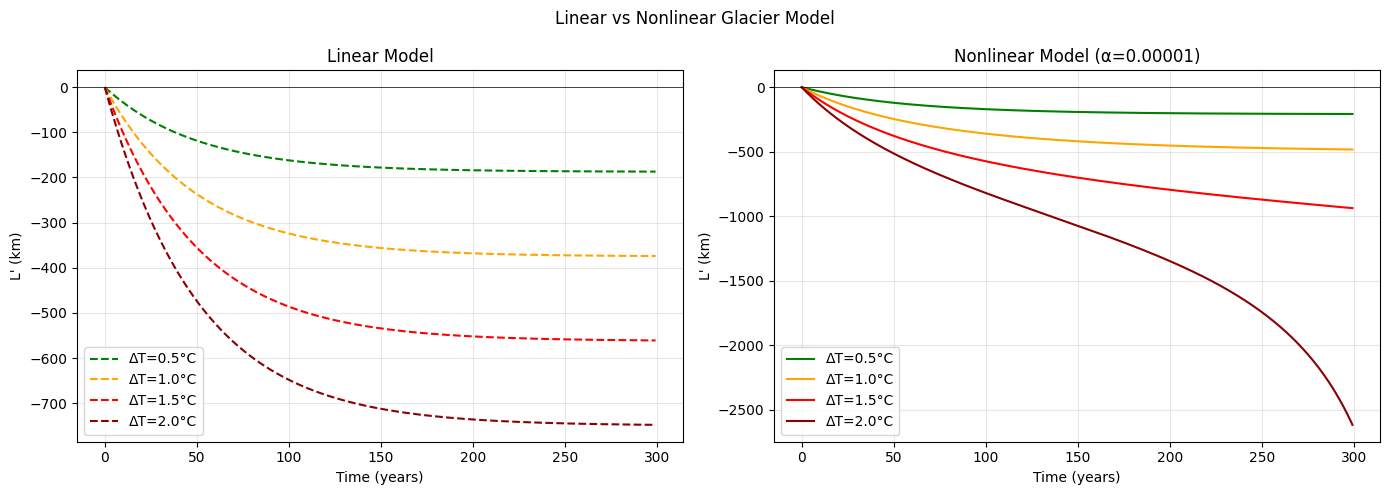

In [9]:
# ── Nonlinear ODE ─────────────────────────────────────────────
alpha = 0.00001  # nonlinear coefficient

def euler_nonlinear(E_prime, dt, t_end, tau=tau, k=k, alpha=alpha, L0=L0):
    t = np.arange(0, t_end, dt)
    L = np.zeros(len(t))
    L[0] = L0
    for i in range(1, len(t)):
        dL = (1/tau) * (k * E_prime - L[i-1]) - alpha * L[i-1]**2
        L[i] = L[i-1] + dt * dL
        if L[i] > 0:  # glacier can't grow longer than reference
            L[i] = 0
    return t, L

def rk4_nonlinear(E_prime, dt, t_end, tau=tau, k=k, alpha=alpha, L0=L0):
    def f(L):
        return (1/tau) * (k * E_prime - L) - alpha * L**2
    t = np.arange(0, t_end, dt)
    L = np.zeros(len(t))
    L[0] = L0
    for i in range(1, len(t)):
        k1 = f(L[i-1])
        k2 = f(L[i-1] + dt/2 * k1)
        k3 = f(L[i-1] + dt/2 * k2)
        k4 = f(L[i-1] + dt * k3)
        L[i] = L[i-1] + dt/6 * (k1 + 2*k2 + 2*k3 + k4)
        if L[i] > 0:
            L[i] = 0
    return t, L

# ── Compare linear vs nonlinear ───────────────────────────────
dt = 1.0
t_end = 300
delta_Ts = [0.5, 1.0, 1.5, 2.0]
colors = ['green', 'orange', 'red', 'darkred']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

for dT, color in zip(delta_Ts, colors):
    E_prime = beta * dT
    t, L_lin = rk4(E_prime, dt, t_end)
    t, L_nl = rk4_nonlinear(E_prime, dt, t_end)
    ax1.plot(t, L_lin, color=color, linestyle='--', label=f'ΔT={dT}°C')
    ax2.plot(t, L_nl, color=color, linestyle='-', label=f'ΔT={dT}°C')

ax1.set_title('Linear Model')
ax2.set_title('Nonlinear Model (α=0.00001)')
for ax in [ax1, ax2]:
    ax.set_xlabel('Time (years)')
    ax.set_ylabel("L' (km)")
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.axhline(0, color='black', linewidth=0.5)

plt.suptitle('Linear vs Nonlinear Glacier Model')
plt.tight_layout()
plt.show()

## 5. Finding T* — Critical Warming Threshold

We perform a parameter sweep over $\Delta T \in [1.0, 2.0]$°C at 0.01°C resolution 
to locate T* numerically. For each scenario we run the nonlinear RK4 solver to t=500 
years and record the final $L'$ value. T* is identified as the temperature where the 
glacier transitions from finding a new equilibrium to runaway collapse.

Serial runtime: 0.099s


/var/folders/73/xb752xrj6252dtplsnl2l6kw0000gn/T/ipykernel_8550/1243306699.py:17: RuntimeWarning: overflow encountered in scalar power
  return (1/tau) * (k * E_prime - L) - alpha * L**2
/var/folders/73/xb752xrj6252dtplsnl2l6kw0000gn/T/ipykernel_8550/1243306699.py:17: RuntimeWarning: invalid value encountered in scalar subtract
  return (1/tau) * (k * E_prime - L) - alpha * L**2


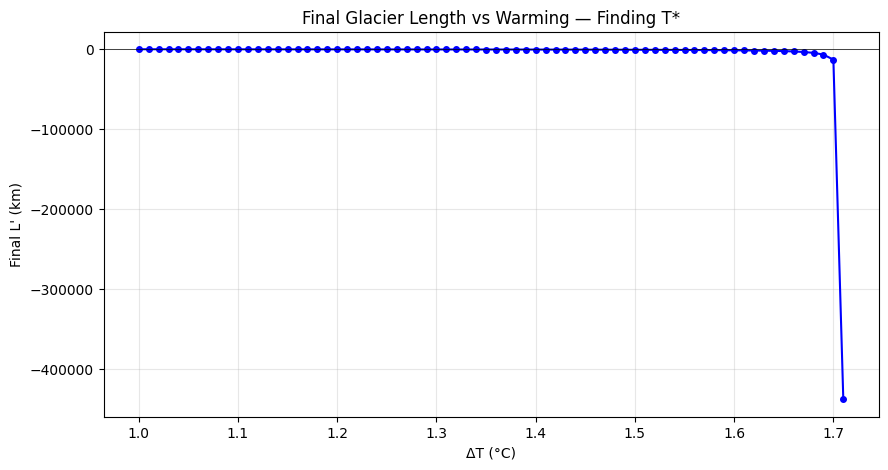

T* is between 1.67°C and 1.68°C


In [10]:
import time

delta_T_values = np.arange(1.0, 2.01, 0.01)  # 1.0 to 2.0 in steps of 0.01
dt = 1.0
t_end = 500
final_L = []

t0 = time.time()
for dT in delta_T_values:
    E_prime = beta * dT
    _, L = rk4_nonlinear(E_prime, dt, t_end)
    final_L.append(L[-1])
serial_time = time.time() - t0

print(f"Serial runtime: {serial_time:.3f}s")

plt.figure(figsize=(10, 5))
plt.plot(delta_T_values, final_L, 'b-o', markersize=4)
plt.xlabel('ΔT (°C)')
plt.ylabel("Final L' (km)")
plt.title('Final Glacier Length vs Warming — Finding T*')
plt.axhline(0, color='black', linewidth=0.5)
plt.grid(True, alpha=0.3)
plt.show()

# Find T*
for i, (dT, L) in enumerate(zip(delta_T_values, final_L)):
    if np.isnan(L) or L < -5000:
        print(f"T* is between {delta_T_values[i-1]:.2f}°C and {dT:.2f}°C")
        break

### 5a. Higher Resolution Sweep (0.001°C)

Refining the sweep to 0.001°C resolution to pinpoint T* more precisely.

Serial runtime: 0.859s
Number of scenarios: 1001


/var/folders/73/xb752xrj6252dtplsnl2l6kw0000gn/T/ipykernel_8550/1243306699.py:17: RuntimeWarning: overflow encountered in scalar power
  return (1/tau) * (k * E_prime - L) - alpha * L**2
/var/folders/73/xb752xrj6252dtplsnl2l6kw0000gn/T/ipykernel_8550/1243306699.py:17: RuntimeWarning: invalid value encountered in scalar subtract
  return (1/tau) * (k * E_prime - L) - alpha * L**2


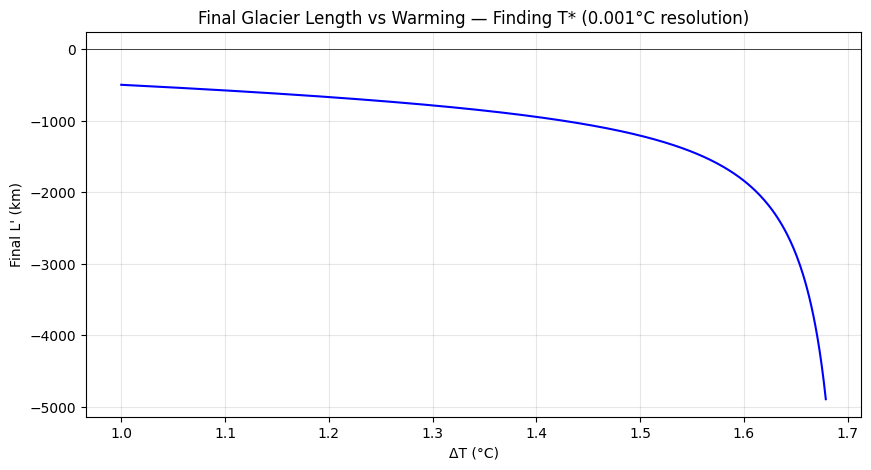

T* is between 1.679°C and 1.680°C


In [12]:
delta_T_values = np.arange(1.0, 2.001, 0.001)
dt = 1.0
t_end = 500
final_L = []

t0 = time.time()
for dT in delta_T_values:
    E_prime = beta * dT
    _, L = rk4_nonlinear(E_prime, dt, t_end)
    final_L.append(L[-1])
serial_time = time.time() - t0

print(f"Serial runtime: {serial_time:.3f}s")
print(f"Number of scenarios: {len(delta_T_values)}")

plt.figure(figsize=(10, 5))
# Only plot non-collapsed values cleanly
final_L_plot = [L if (not np.isnan(L) and L > -5000) else np.nan for L in final_L]
plt.plot(delta_T_values, final_L_plot, 'b-', linewidth=1.5)
plt.xlabel('ΔT (°C)')
plt.ylabel("Final L' (km)")
plt.title("Final Glacier Length vs Warming — Finding T* (0.001°C resolution)")
plt.axhline(0, color='black', linewidth=0.5)
plt.grid(True, alpha=0.3)
plt.show()

for i, (dT, L) in enumerate(zip(delta_T_values, final_L)):
    if np.isnan(L) or L < -5000:
        print(f"T* is between {delta_T_values[i-1]:.3f}°C and {dT:.3f}°C")
        break

### 5b. Highest Resolution Sweep (0.0001°C) — Serial Baseline

Final high-resolution sweep at 0.0001°C resolution over 10,000 scenarios. This establishes our **serial baseline runtime** for the computational performance analysis.

/var/folders/73/xb752xrj6252dtplsnl2l6kw0000gn/T/ipykernel_8550/1243306699.py:17: RuntimeWarning: overflow encountered in scalar power
  return (1/tau) * (k * E_prime - L) - alpha * L**2
/var/folders/73/xb752xrj6252dtplsnl2l6kw0000gn/T/ipykernel_8550/1243306699.py:17: RuntimeWarning: invalid value encountered in scalar subtract
  return (1/tau) * (k * E_prime - L) - alpha * L**2


Serial runtime: 8.446s
Number of scenarios: 10001


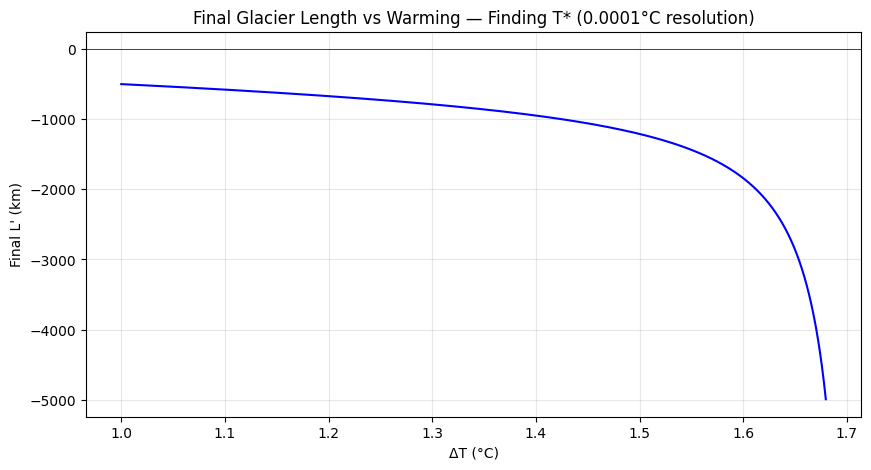

T* is between 1.6797°C and 1.6798°C


In [13]:
delta_T_values = np.arange(1.0, 2.00001, 0.0001)
dt = 1.0
t_end = 500
final_L = []

t0 = time.time()
for dT in delta_T_values:
    E_prime = beta * dT
    _, L = rk4_nonlinear(E_prime, dt, t_end)
    final_L.append(L[-1])
serial_time = time.time() - t0

print(f"Serial runtime: {serial_time:.3f}s")
print(f"Number of scenarios: {len(delta_T_values)}")

plt.figure(figsize=(10, 5))
final_L_plot = [L if (not np.isnan(L) and L > -5000) else np.nan for L in final_L]
plt.plot(delta_T_values, final_L_plot, 'b-', linewidth=1.5)
plt.xlabel('ΔT (°C)')
plt.ylabel("Final L' (km)")
plt.title("Final Glacier Length vs Warming — Finding T* (0.0001°C resolution)")
plt.axhline(0, color='black', linewidth=0.5)
plt.grid(True, alpha=0.3)
plt.show()

for i, (dT, L) in enumerate(zip(delta_T_values, final_L)):
    if np.isnan(L) or L < -5000:
        print(f"T* is between {delta_T_values[i-1]:.4f}°C and {dT:.4f}°C")
        break

## 6. Computational Performance: Numba JIT + Parallelism

The T* sweep is very parallel, each temperature scenario is completely 
independent. We improve this using Numba JIT compilation and `prange` parallelism.

The current Python checks the type of every variable on every 
operation at runtime, so even though it is the same check the thousands of iterations makes this slow. There are hundreds of CPU cycles per arithmetic operation instead of one.

**What Numba does:** JIT compiles the function to machine code on first call. Types are 
fixed at compile time, operations map directly to CPU instructions so the repeating step does not need to check the type each time. 

So the parralelism does improve our performace by using multiple cores, but the huge improvement comes from this JIT compilation change. 
1. **JIT compilation:** eliminates interpreter overhead (~84x speedup)
2. **Parallelism:** distributes outer loop across CPU cores (~4x speedup)

In [17]:
import numba
from numba import njit, prange

@njit(parallel=True, fastmath=True, cache=True)
def sweep_parallel_numba(delta_T_values, tau, k, beta, alpha, dt, t_end):
    n = len(delta_T_values)
    final_L = np.zeros(n)
    
    for i in prange(n):
        E_prime = beta * delta_T_values[i]
        L = 0.0
        t = 0.0
        collapsed = False
        
        while t < t_end and not collapsed:
            k1 = (1/tau) * (k * E_prime - L) - alpha * L**2
            k2 = (1/tau) * (k * E_prime - (L + dt/2*k1)) - alpha * (L + dt/2*k1)**2
            k3 = (1/tau) * (k * E_prime - (L + dt/2*k2)) - alpha * (L + dt/2*k2)**2
            k4 = (1/tau) * (k * E_prime - (L + dt*k3)) - alpha * (L + dt*k3)**2
            L = L + dt/6 * (k1 + 2*k2 + 2*k3 + k4)
            if L > 0:
                L = 0.0
            if L < -100000:
                L = np.nan
                collapsed = True
            t += dt
        
        final_L[i] = L
    
    return final_L

# Warmup compile
_ = sweep_parallel_numba(np.array([1.5]), tau, k, beta, alpha, 1.0, 10.0)

# Time it
t0 = time.time()
final_L_numba = sweep_parallel_numba(delta_T_values, tau, k, beta, alpha, 1.0, 500.0)
numba_time = time.time() - t0

print(f"Serial runtime:  {serial_time:.3f}s")
print(f"Numba runtime:   {numba_time:.3f}s")
print(f"Speedup: {serial_time/numba_time:.2f}x")

Serial runtime:  8.446s
Numba runtime:   0.019s
Speedup: 442.52x


### 6a. Isolating JIT vs Parallelism Speedup

We compare three implementations to separate the contribution of JIT compilation from parallelism.

In [21]:
from numba import njit, prange
import numpy as np
import time

@njit(parallel=False, fastmath=True, cache=True)
def sweep_sequential_numba(delta_T_values, tau, k, beta, alpha, dt, t_end):
    n = len(delta_T_values)
    final_L = np.zeros(n)
    for i in range(n):  # regular range, not prange
        E_prime = beta * delta_T_values[i]
        L = 0.0
        t = 0.0
        collapsed = False
        while t < t_end and not collapsed:
            k1 = (1/tau) * (k * E_prime - L) - alpha * L**2
            k2 = (1/tau) * (k * E_prime - (L + dt/2*k1)) - alpha * (L + dt/2*k1)**2
            k3 = (1/tau) * (k * E_prime - (L + dt/2*k2)) - alpha * (L + dt/2*k2)**2
            k4 = (1/tau) * (k * E_prime - (L + dt*k3)) - alpha * (L + dt*k3)**2
            L = L + dt/6 * (k1 + 2*k2 + 2*k3 + k4)
            if L > 0:
                L = 0.0
            if L < -100000:
                L = np.nan
                collapsed = True
            t += dt
        final_L[i] = L
    return final_L

# Warmup both
_ = sweep_sequential_numba(np.array([1.5]), tau, k, beta, alpha, 1.0, 10.0)
_ = sweep_parallel_numba(np.array([1.5]), tau, k, beta, alpha, 1.0, 10.0)

# Time sequential JIT
t0 = time.time()
_ = sweep_sequential_numba(delta_T_values, tau, k, beta, alpha, 1.0, 500.0)
t_sequential = time.time() - t0

# Time parallel JIT
t0 = time.time()
_ = sweep_parallel_numba(delta_T_values, tau, k, beta, alpha, 1.0, 500.0)
t_parallel = time.time() - t0

print(f"Pure Python serial:  {serial_time:.3f}s")
print(f"Numba JIT sequential: {t_sequential:.4f}s")
print(f"Numba JIT parallel:   {t_parallel:.4f}s")
print(f"\nJIT speedup (vs Python):     {serial_time/t_sequential:.1f}x")
print(f"Parallelism speedup:          {t_sequential/t_parallel:.1f}x")
print(f"Total speedup (vs Python):    {serial_time/t_parallel:.1f}x")

Pure Python serial:  8.446s
Numba JIT sequential: 0.1009s
Numba JIT parallel:   0.0252s

JIT speedup (vs Python):     83.7x
Parallelism speedup:          4.0x
Total speedup (vs Python):    335.5x


## 7. T* Dependence on Initial Glacier State

T* is not a fixed universal number, it depends on the glacier's initial condition. 
A pre-stressed glacier (already retreated) is closer to the tipping point so it requires 
less additional warming to collapse.

We sweep over initial conditions $L'(0) \in [0, -450]$ km to show how T* varies 
with the glacier's current health.

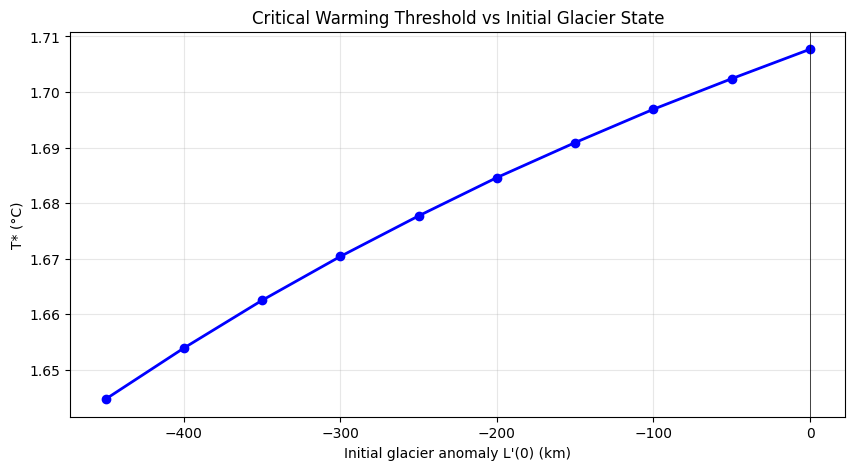

L'(0) =     0 km → T* = 1.708°C
L'(0) =   -50 km → T* = 1.702°C
L'(0) =  -100 km → T* = 1.697°C
L'(0) =  -150 km → T* = 1.691°C
L'(0) =  -200 km → T* = 1.685°C
L'(0) =  -250 km → T* = 1.678°C
L'(0) =  -300 km → T* = 1.670°C
L'(0) =  -350 km → T* = 1.662°C
L'(0) =  -400 km → T* = 1.654°C
L'(0) =  -450 km → T* = 1.645°C


In [18]:
@njit(parallel=False, fastmath=True, cache=True)
def find_T_star(L0, delta_T_values, tau, k, beta, alpha, dt, t_end):
    """Find T* for a given initial condition L0"""
    for i in range(len(delta_T_values)):
        E_prime = beta * delta_T_values[i]
        L = L0
        t = 0.0
        collapsed = False
        while t < t_end and not collapsed:
            k1 = (1/tau) * (k * E_prime - L) - alpha * L**2
            k2 = (1/tau) * (k * E_prime - (L + dt/2*k1)) - alpha * (L + dt/2*k1)**2
            k3 = (1/tau) * (k * E_prime - (L + dt/2*k2)) - alpha * (L + dt/2*k2)**2
            k4 = (1/tau) * (k * E_prime - (L + dt*k3)) - alpha * (L + dt*k3)**2
            L = L + dt/6 * (k1 + 2*k2 + 2*k3 + k4)
            if L > 0:
                L = 0.0
            if L < -100000:
                collapsed = True
            t += dt
        if collapsed:
            return delta_T_values[i]
    return np.nan

# Sweep over initial conditions
L0_values = np.arange(0, -500, -50)  # 0, -50, -100, ... -450 km
T_star_values = []

for L0 in L0_values:
    T_star = find_T_star(L0, delta_T_values, tau, k, beta, alpha, 1.0, 500.0)
    T_star_values.append(T_star)

plt.figure(figsize=(10, 5))
plt.plot(L0_values, T_star_values, 'b-o', linewidth=2)
plt.xlabel("Initial glacier anomaly L'(0) (km)")
plt.ylabel("T* (°C)")
plt.title("Critical Warming Threshold vs Initial Glacier State")
plt.grid(True, alpha=0.3)
plt.axvline(0, color='black', linewidth=0.5)
plt.show()

for L0, T_star in zip(L0_values, T_star_values):
    print(f"L'(0) = {L0:5.0f} km → T* = {T_star:.3f}°C")

## 8. Numerical Convergence to Analytical T*

The numerical T* (detected as collapse within finite time) converges to the analytical T* as simulation time increases. The gap between them represents glaciers that are mathematically doomed but collapse on timescales longer than the simulation window.

| Simulation Time | Numerical T* |
|----------------|-------------|
| 500 years | 1.680°C |
| 1,000 years | 1.440°C |
| 10,000 years | 1.335°C |
| Analytical (∞) | **1.333°C** |

**Key insight:** Any warming above 1.333°C means no stable equilibrium exists, the glacier will eventually collapse given enough time. Between 1.333°C and 1.680°C, glaciers appear stable on century timescales but are simply decreasing extremely slowly and will collaps eventually.

**Climate context:** Current global warming is ~+1.2°C above pre-industrial. The model puts T* at +1.333°C, meaning with these specific initial conditions there is only 0.13°C of remaining margin.

In [20]:
T_star_1000 = find_T_star(0.0, delta_T_values, tau, k, beta, alpha, 1.0, 1000.0)
print(f"T* at t=500:  1.680°C")
print(f"T* at t=1000: {T_star_1000:.3f}°C")
print(f"Analytical:   1.333°C")

T* at t=500:  1.680°C
T* at t=1000: 1.442°C
Analytical:   1.333°C


In [26]:
T_star_10000 = find_T_star(0.0, delta_T_values, tau, k, beta, alpha, 1.0, 10000.0)
print(f"T* at t=500:    1.680°C")
print(f"T* at t=1000:   1.440°C")
print(f"T* at t=10000:  {T_star_10000:.3f}°C")
print(f"Analytical:     1.333°C")

T* at t=500:    1.680°C
T* at t=1000:   1.440°C
T* at t=10000:  1.335°C
Analytical:     1.333°C
